# Tennis Data Analysis


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [5]:
import pandas as pd
import glob

# Load and merge all tennis datasets
files = glob.glob("data/tennis-*.csv")  
dfs = []

for f in files:
    gender = 'men' if '-m-' in f else 'women'
    df = pd.read_csv(f, compression='infer')
    df['Gender'] = gender
    dfs.append(df)

tennis_df = pd.concat(dfs, ignore_index=True)

print("Combined shape:", tennis_df.shape)
tennis_df.head()

print(tennis_df.columns)
print(tennis_df.isna().sum())
print(tennis_df['Tournament'].value_counts())


Combined shape: (2735729, 18)
Index(['Date', 'Tournament', 'Round', 'Player1', 'Player2', 'Point', 'Shot',
       'Serve', 'ServingPlayer', 'WinningPlayer', 'ShotHand', 'ShotType',
       'ShotDirection', 'ServeDirection', 'ShotDepth', 'OutcomeType',
       'ErrorType', 'Gender'],
      dtype='object')
Date                    0
Tournament              0
Round                   0
Player1                 0
Player2                 0
Point                   0
Shot                    0
Serve                   0
ServingPlayer           0
WinningPlayer           0
ShotHand           737233
ShotType             2706
ShotDirection      769370
ServeDirection    2001192
ShotDepth         2059855
OutcomeType       2200927
ErrorType         2196324
Gender                  0
dtype: int64
Tournament
Australian_Open            815741
US_Open                    734393
Roland_Garros              611141
Wimbledon                  558897
Australian_Open_Juniors      8729
Wimbledon_Juniors            4901


Many shot hand and serve direction values. Serve direction makes sense because it is only recorded on the 1st or 2nd serve and not all shots. Shot hand will be missing for serves. Outcome type, Error type, and Shot depth are also missing many values. 

Focus on complete columns and meaningful columns. Can remove people's names as they are not predicitive. 

Also, possible to build two views of prediction. One based of serving and one based of a general shot. 

In [6]:
cols_to_drop = [
    'Player1',       # static identifiers
    'Player2',       # static identifiers
    'Date', 
    'Tournament',    
]

df_clean = tennis_df.drop(columns=cols_to_drop)
print("Remaining columns:", df_clean.columns.tolist())

Remaining columns: ['Round', 'Point', 'Shot', 'Serve', 'ServingPlayer', 'WinningPlayer', 'ShotHand', 'ShotType', 'ShotDirection', 'ServeDirection', 'ShotDepth', 'OutcomeType', 'ErrorType', 'Gender']


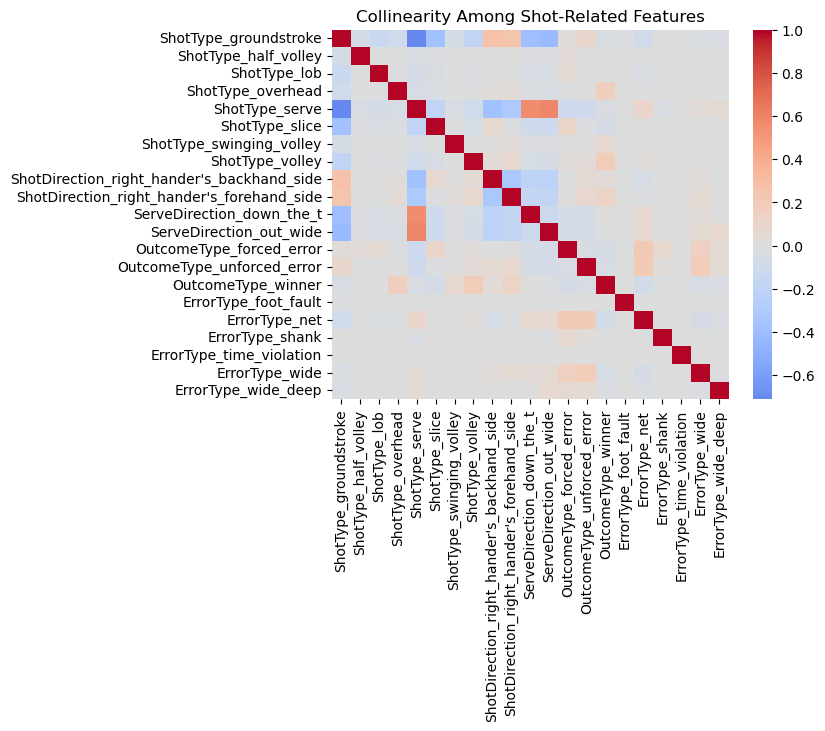

Series([], dtype: float64)

In [8]:
# encode categorical values to look at collinearlity

cols_focus = ['ShotType', 'ShotDirection', 'ServeDirection', 'OutcomeType', 'ErrorType']
encoded_focus = pd.get_dummies(tennis_df[cols_focus], drop_first=True)
sns.heatmap(encoded_focus.corr(), cmap="coolwarm", center=0)
plt.title("Collinearity Among Shot-Related Features")
plt.show()



There are no strong correlations between shot related featuers. Most are largely independent. 

I will start exploring wether a specific serve effects winning. 

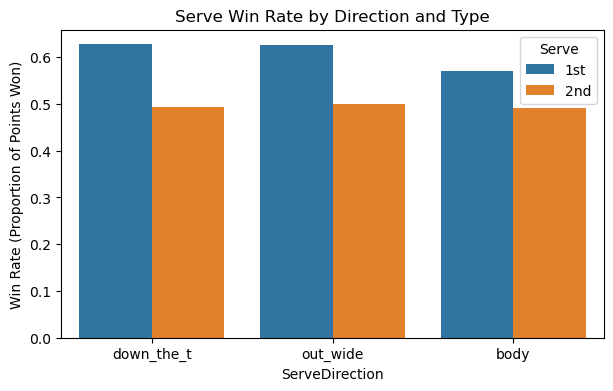

In [9]:
tennis_df['DidServerWin'] = tennis_df['WinningPlayer'] == tennis_df['ServingPlayer']

# focus on rows where Serve is '1st' or '2nd'
serve_df = tennis_df[tennis_df['Serve'].isin(['1st', '2nd'])]

serve_outcomes = (
    serve_df.groupby(['ServeDirection', 'Serve'])
    ['DidServerWin']
    .mean()
    .reset_index()
    .sort_values('DidServerWin', ascending=False)
)
serve_outcomes

plt.figure(figsize=(7,4))
sns.barplot(data=serve_outcomes, x='ServeDirection', y='DidServerWin', hue='Serve')
plt.title("Serve Win Rate by Direction and Type")
plt.ylabel("Win Rate (Proportion of Points Won)")
plt.show()



/var/folders/v9/1w1yw15d14d35xlpvslb973m0000gn/T/ipykernel_62012/1507824806.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shot_summary, x='DidWinPoint', y='ShotType', palette='crest')


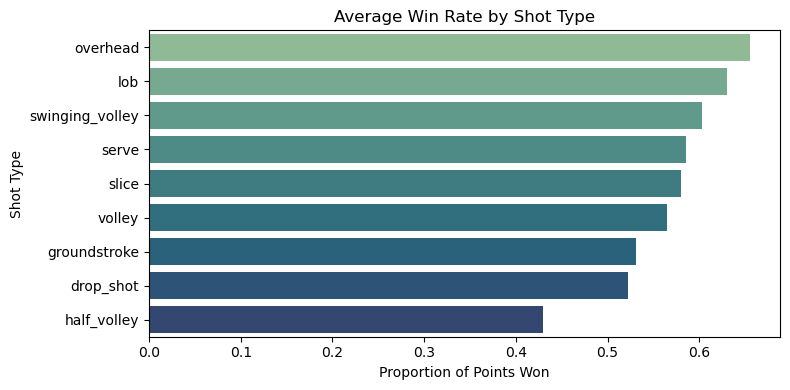

/var/folders/v9/1w1yw15d14d35xlpvslb973m0000gn/T/ipykernel_62012/1507824806.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=direction_summary, x='DidWinPoint', y='ShotDirection', palette='viridis')


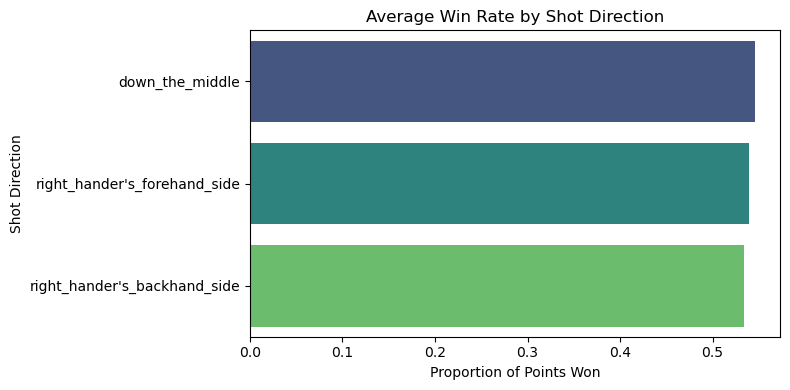

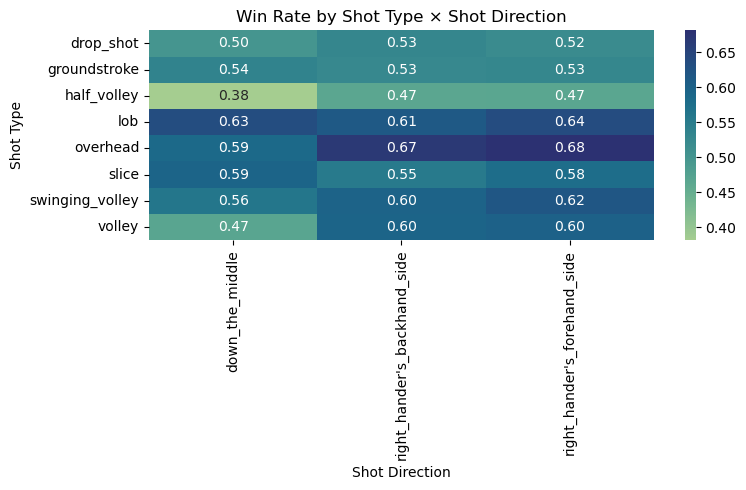

In [14]:
# Find the last shot in each point
tennis_df['DidWinPoint'] = tennis_df['ServingPlayer'] == tennis_df['WinningPlayer']


shot_summary = (
    tennis_df.groupby('ShotType')['DidWinPoint']
    .mean()
    .reset_index()
    .sort_values('DidWinPoint', ascending=False)
)

plt.figure(figsize=(8,4))
sns.barplot(data=shot_summary, x='DidWinPoint', y='ShotType', palette='crest')
plt.title("Average Win Rate by Shot Type")
plt.xlabel("Proportion of Points Won")
plt.ylabel("Shot Type")
plt.tight_layout()
plt.show()

direction_summary = (
    tennis_df.groupby('ShotDirection')['DidWinPoint']
    .mean()
    .reset_index()
    .sort_values('DidWinPoint', ascending=False)
)

plt.figure(figsize=(8,4))
sns.barplot(data=direction_summary, x='DidWinPoint', y='ShotDirection', palette='viridis')
plt.title("Average Win Rate by Shot Direction")
plt.xlabel("Proportion of Points Won")
plt.ylabel("Shot Direction")
plt.tight_layout()
plt.show()

pivot = (
    tennis_df.pivot_table(values='DidWinPoint',
                          index='ShotType', columns='ShotDirection',
                          aggfunc='mean')
)
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='crest')
plt.title("Win Rate by Shot Type × Shot Direction")
plt.xlabel("Shot Direction")
plt.ylabel("Shot Type")
plt.tight_layout()
plt.show()


My role is to build an LSTM model for predicitng tennis shots and wins. Serve and Serve Direction are the initial features for this model. The Shot Type and Shot Direction will be the sequence features. The Shot and Point values will be the time feature for the model, describing how far along in the game the players are. Predicition targets can include the next shot type, direction, outcome of the game, and wether the next shot will be the scoring shot. 